In [2]:
#loading/preparing data

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import mean_squared_error, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import SGD

df = pd.read_csv('final_project_data.csv')

#get cols
x_cols = df.columns[:-1]
y_col = df.columns[-1]

#get data
x = df[x_cols].values.astype(np.float64)
y = df[y_col].values.astype(int)

#split into train and test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, 
random_state=42)


In [3]:
#setting up MLP

from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV

#make MLP
def build_clf(hidden1 = 32, rate = 0.01, dropout_rate = 0, **kwargs):
    model = Sequential([
        Input(shape=(x.shape[1],)),
        Dense(hidden1, activation = 'relu'),
        Dropout(dropout_rate),
        Dense(1, activation = 'sigmoid')
    ])

#https://www.tensorflow.org/api_docs/python/tf/keras/Model
    
    model.compile(optimizer=SGD(learning_rate = rate), loss = 'binary_crossentropy',
                  metrics = ['accuracy'])
    return model

model = KerasClassifier(model=build_clf, epochs = 50, batch_size = 128, verbose = 1)

#test diff params
params = {
    'model__hidden1':[32, 64, 128],
    'model__rate':[0.0001, 0.0005, 0.001, 0.005, 0.01],
    'epochs': [50, 100, 150],
    'model__dropout_rate': [0, 0.1, 0.3, 0.5]
}
#class sklearn.model_selection.RandomizedSearchCV(estimator, param_distributions, 
#*, n_iter=10, scoring=None, n_jobs=None, refit=True, cv=None, verbose=0, 
#pre_dispatch='2*n_jobs', random_state=None, error_score=nan, return_train_score=False)

#using random search 
random_search = RandomizedSearchCV(estimator = model, param_distributions = params,
                    n_iter = 25, scoring = 'f1', cv = 3, verbose = 1,
                    random_state = 42)



In [53]:
#https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html
from sklearn.utils.class_weight import compute_class_weight
#majority of data was class 1, so model just learned to always predict 1
#had to increase weight of class 0 so it would actually predict
import random
np.random.seed(42)
random.seed(42)

classes = np.array([0,1])
weights = compute_class_weight(class_weight="balanced", classes = classes, y = y_train)

weight_class = {0: weights[0], 1: weights[1]}
print(weight_class)

{0: 4.87685930260912, 1: 0.5571185826903257}


In [5]:
#fitting

#fit on training data
rs = random_search.fit(x_train,y_train, class_weight=weight_class)

print("Best CV F1: ", rs.best_score_)
print("Best Params: ", rs.best_params_)


Fitting 3 folds for each of 25 candidates, totalling 75 fits
Epoch 1/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5242 - loss: 0.7642
Epoch 2/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5521 - loss: 0.6933
Epoch 3/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5437 - loss: 0.6918
Epoch 4/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5598 - loss: 0.6910
Epoch 5/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5236 - loss: 0.6907
Epoch 6/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5249 - loss: 0.6894
Epoch 7/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5392 - loss: 0.6895
Epoch 8/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5432 - loss: 0.6893
Epoch 9/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5264 - loss: 0.6898
Epoch 10/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5440 - loss: 0.6885
Epoch 11/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5409 - loss

In [87]:
#final best model + f1 scores eval

#use test data to get f1 stats
from sklearn.metrics import f1_score
np.random.seed(42)
random.seed(42)

from sklearn.metrics import classification_report

best_model = rs.best_estimator_


#so we can see error of each epoch
#history = best_model.fit(x_train, y_train, class_weight = weight_class, verbose = 0)

y_pred = best_model.predict(x_test)

#full confusion matrix printed below graph
cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix:")
print(cm)

f1 = f1_score(y_test, y_pred)

print("F1 Score: ", f1)
print("Classification")
print(classification_report(y_test,y_pred))


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion matrix:
[[ 2006     0]
 [ 5972 12022]]
F1 Score:  0.8010394456289979
Classification
              precision    recall  f1-score   support

           0       0.25      1.00      0.40      2006
           1       1.00      0.67      0.80     17994

    accuracy                           0.70     20000
   macro avg       0.63      0.83      0.60     20000
weighted avg       0.92      0.70      0.76     20000



Text(0.5, 1.0, 'Orignal 1 Hidden Layer CM')

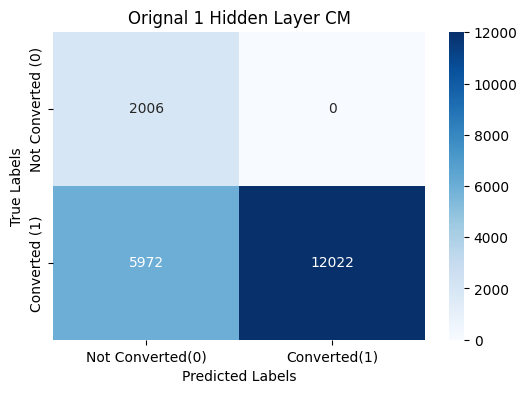

In [94]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm, 
    annot = True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Converted(0)', 'Converted(1)'],
    yticklabels=['Not Converted (0)', 'Converted (1)'],
)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Orignal 1 Hidden Layer CM')

In [103]:
y_prob = best_model.predict_proba(x_test)

thresholds = np.arange(0.1, 0.5, 0.01)
best_f1 = 0
best_threshold = 0
y_pred_best = (y_prob[:,1] > 0.5).astype(int)
print(y_pred_best)
for i in thresholds :
    temp = (y_prob[:,1] > i).astype(int)
    
    score = f1_score(y_test, temp)
    if score > best_f1:
        best_f1 = score
        best_threshold = i
        y_pred_best = temp

cm_best = confusion_matrix(y_test, y_pred_best)

print("Confusion matrix:")
print(cm_best)

print(classification_report(y_test,y_pred_best))

print("F1 Score: ", best_f1)
print("Threshold: ", best_threshold)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[1 1 1 ... 0 0 0]
Confusion matrix:
[[ 1191   815]
 [  353 17641]]
              precision    recall  f1-score   support

           0       0.77      0.59      0.67      2006
           1       0.96      0.98      0.97     17994

    accuracy                           0.94     20000
   macro avg       0.86      0.79      0.82     20000
weighted avg       0.94      0.94      0.94     20000

F1 Score:  0.9679561042524005
Threshold:  0.32999999999999985


Text(0.5, 1.0, '0.3 Threshold 1 Hidden Layer CM')

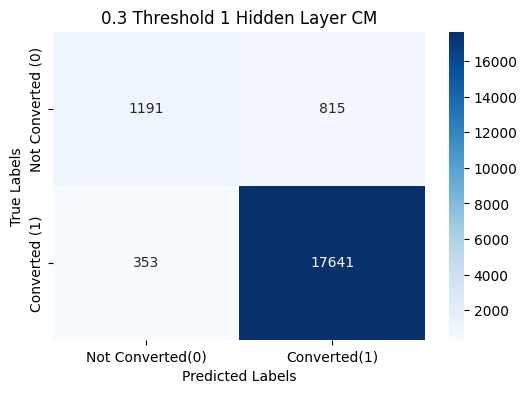

In [104]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm_best, 
    annot = True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Converted(0)', 'Converted(1)'],
    yticklabels=['Not Converted (0)', 'Converted (1)'],
)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('0.3 Threshold 1 Hidden Layer CM')

In [120]:
best_model.model_.save('1layer.keras')

In [125]:



#so we can see error of each epoch
#history = best_model.fit(x_train, y_train, class_weight = weight_class, verbose = 0)

y_pred_test = (test.predict(x_test)>0.33).astype(int)

#full confusion matrix printed below graph
cm_test = confusion_matrix(y_test, y_pred_test)

print("Confusion matrix:")
print(cm_test)

f1_test = f1_score(y_test, y_pred_test)

print("F1 Score: ", f1_test)
print("Classification")
print(classification_report(y_test,y_pred_test))

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Confusion matrix:
[[ 1191   815]
 [  353 17641]]
F1 Score:  0.9679561042524005
Classification
              precision    recall  f1-score   support

           0       0.77      0.59      0.67      2006
           1       0.96      0.98      0.97     17994

    accuracy                           0.94     20000
   macro avg       0.86      0.79      0.82     20000
weighted avg       0.94      0.94      0.94     20000



In [27]:
#2 layers
#make MLP
def build_clf2(hidden1 = 32, hidden2 = 32, rate = 0.01, **kwargs):
    model2 = Sequential([
        Input(shape=(x.shape[1],)),
        Dense(hidden1, activation = 'relu'),
        Dense(hidden2, activation = 'relu'),
        Dense(1, activation = 'sigmoid')
    ])

#https://www.tensorflow.org/api_docs/python/tf/keras/Model
    
    model2.compile(optimizer=SGD(learning_rate = rate), loss = 'binary_crossentropy',
                  metrics = ['accuracy'])
    return model2

model2 = KerasClassifier(model=build_clf2, epochs = 10, batch_size = 128, verbose = 1)

#test diff params
params2 = {
    'model__hidden1':[32, 64, 128],
    'model__hidden2':[32, 64, 128],
    'model__rate':[0.0001, 0.0005, 0.001, 0.005, 0.01],
    'epochs': [10, 50, 100],
    'model__dropout_rate': [0, 0.1, 0.3, 0.5]
}
#class sklearn.model_selection.RandomizedSearchCV(estimator, param_distributions, 
#*, n_iter=10, scoring=None, n_jobs=None, refit=True, cv=None, verbose=0, 
#pre_dispatch='2*n_jobs', random_state=None, error_score=nan, return_train_score=False)

#using random search 
random_search2 = RandomizedSearchCV(estimator = model2, param_distributions = params2,
                    n_iter = 40, scoring = 'f1', cv = 3, verbose = 1, 
                    random_state = 42)


In [18]:
#fitting layer 2

#fit on training data
rs2 = random_search2.fit(x_train,y_train, class_weight=weight_class)

print("Best CV F1: ", rs2.best_score_)
print("Best Params: ", rs2.best_params_)


Fitting 3 folds for each of 40 candidates, totalling 120 fits
Epoch 1/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5237 - loss: 0.7400
Epoch 2/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4958 - loss: 0.6937
Epoch 3/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5072 - loss: 0.6919
Epoch 4/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5366 - loss: 0.6908
Epoch 5/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5397 - loss: 0.6907
Epoch 6/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5301 - loss: 0.6913
Epoch 7/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5282 - loss: 0.6901
Epoch 8/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5361 - loss: 0.6896
Epoch 9/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5351 - loss: 0.6890
Epoch 10/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5192 - loss: 0.6884
Epoch 11/50
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5501 - los

In [23]:
#final best model + f1 scores eval

#use test data to get f1 stats
from sklearn.metrics import f1_score

best_model2 = rs.best_estimator_

#so we can see error of each epoch
history2 = best_model2.fit(x_train, y_train,
                    validation_data = (x_test, y_test), class_weight = weight_class, verbose = 1)

y_pred2 = best_model2.predict(x_test)

#full confusion matrix printed below graph
cm2 = confusion_matrix(y_test, y_pred2)

print("Confusion matrix:")
print(cm2)

f12 = f1_score(y_test, y_pred2)

print("F1 Score: ", f12)


Epoch 1/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5080 - loss: 0.8801 - val_accuracy: 0.4601 - val_loss: 0.6989
Epoch 2/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5268 - loss: 0.7043 - val_accuracy: 0.8067 - val_loss: 0.6488
Epoch 3/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5393 - loss: 0.6941 - val_accuracy: 0.7767 - val_loss: 0.6589
Epoch 4/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5427 - loss: 0.6938 - val_accuracy: 0.3664 - val_loss: 0.7086
Epoch 5/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5484 - loss: 0.6919 - val_accuracy: 0.8573 - val_loss: 0.6164
Epoch 6/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5445 - loss: 0.6913 - val_accuracy: 0.3041 - val_loss: 0.7200
Epoch 7/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5522 - loss: 0.6907 - val_accuracy: 0.4816 - val_loss: 0.6949
Epoch 8/150
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5546 - loss: 0.6906 - val_accu

In [115]:
print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.77      0.24      0.37      2006
           1       0.92      0.99      0.96     17994

    accuracy                           0.92     20000
   macro avg       0.85      0.62      0.66     20000
weighted avg       0.91      0.92      0.90     20000



Text(0.5, 1.0, '2 Hidden Layer CM')

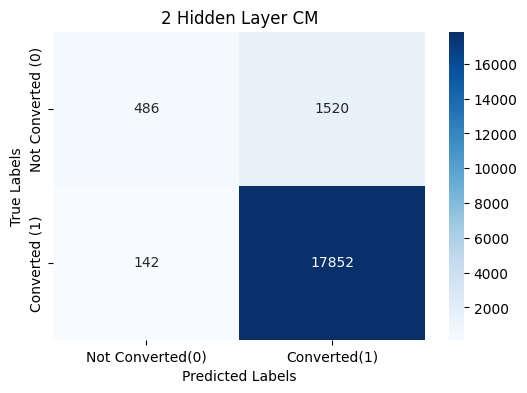

In [117]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm2, 
    annot = True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Converted(0)', 'Converted(1)'],
    yticklabels=['Not Converted (0)', 'Converted (1)'],
)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('2 Hidden Layer CM')

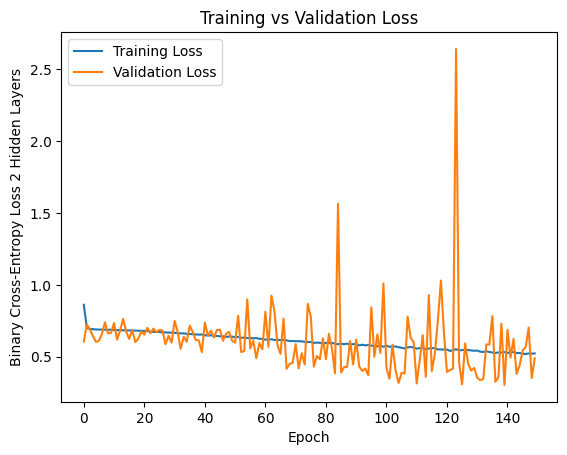

In [52]:
plt.figure()

plt.plot(best_model2.history_["loss"], label="Training Loss")

if "val_loss" in best_model2.history_:
    plt.plot(best_model2.history_["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss 2 Hidden Layers")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [28]:
#2 layers - refining search
#make MLP
def build_clf2refine(hidden1 = 32, hidden2 = 32, rate = 0.01, **kwargs):
    model2refine = Sequential([
        Input(shape=(x.shape[1],)),
        Dense(hidden1, activation = 'relu'),
        Dense(hidden2, activation = 'relu'),
        Dense(1, activation = 'sigmoid')
    ])

#https://www.tensorflow.org/api_docs/python/tf/keras/Model
    
    model2refine.compile(optimizer=SGD(learning_rate = rate), loss = 'binary_crossentropy',
                  metrics = ['accuracy'])
    return model2refine

model2refine = KerasClassifier(model=build_clf2refine, epochs = 10, batch_size = 128, verbose = 1)

#test diff params
params2refine = {
    'model__hidden1':[32, 64, 128],
    'model__hidden2':[32, 64, 128],
    'model__rate':[0.0005, 0.001, 0.005],
    'epochs': [50, 100, 150],
    'model__dropout_rate': [0, 0.1, 0.3, 0.5]
}
#class sklearn.model_selection.RandomizedSearchCV(estimator, param_distributions, 
#*, n_iter=10, scoring=None, n_jobs=None, refit=True, cv=None, verbose=0, 
#pre_dispatch='2*n_jobs', random_state=None, error_score=nan, return_train_score=False)

#using random search 
random_search2refine = RandomizedSearchCV(estimator = model2refine, param_distributions = params2refine,
                    n_iter = 50, scoring = 'f1', cv = 3, verbose = 1, 
                    random_state = 42)


In [29]:
#fitting layer 2

#fit on training data
rs2refine = random_search2refine.fit(x_train,y_train, class_weight=weight_class)

print("Best CV F1: ", rs2refine.best_score_)
print("Best Params: ", rs2refine.best_params_)


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Epoch 1/100
417/417 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5541 - loss: 0.7339
Epoch 2/100
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5417 - loss: 0.7058
Epoch 3/100
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5585 - loss: 0.7044
Epoch 4/100
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5541 - loss: 0.7010
Epoch 5/100
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5595 - loss: 0.6994
Epoch 6/100
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5586 - loss: 0.6962
Epoch 7/100
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5566 - loss: 0.6952
Epoch 8/100
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5583 - loss: 0.6939
Epoch 9/100
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5590 - loss: 0.6909
Epoch 10/100
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5723 - loss: 0.6903
Epoch 11/100
417/417 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0

In [111]:
#final best model + f1 scores eval

#use test data to get f1 stats

np.random.seed(42)
random.seed(42)
best_model2refine = rs2refine.best_estimator_

#so we can see error of each epoch
#history2refine = best_model2refine.fit(x_train, y_train,
                    #validation_data = (x_test, y_test), class_weight = weight_class, verbose = 1)

y_pred2refine = best_model2refine.predict(x_test)

#full confusion matrix printed below graph
cm2refine = confusion_matrix(y_test, y_pred2refine)

print("Confusion matrix:")
print(cm2refine)

f12refine = f1_score(y_test, y_pred2refine)
print(classification_report(y_test,y_pred2refine))

print("F1 Score: ", f12refine)


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion matrix:
[[ 1764   242]
 [ 7062 10932]]
              precision    recall  f1-score   support

           0       0.20      0.88      0.33      2006
           1       0.98      0.61      0.75     17994

    accuracy                           0.63     20000
   macro avg       0.59      0.74      0.54     20000
weighted avg       0.90      0.63      0.71     20000

F1 Score:  0.749588590235875


In [126]:
best_model2refine.model_.save('2layer.keras')

Text(0.5, 1.0, '2 Hidden Layer CM')

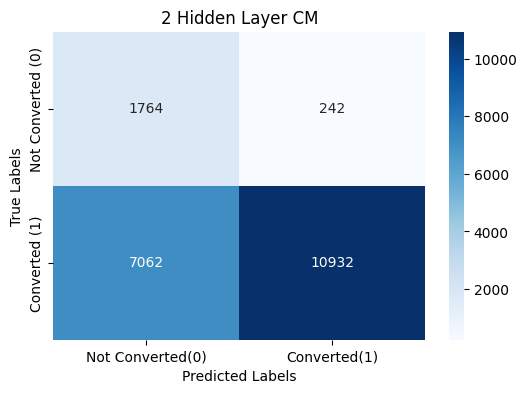

In [112]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm2refine, 
    annot = True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Converted(0)', 'Converted(1)'],
    yticklabels=['Not Converted (0)', 'Converted (1)'],
)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('2 Hidden Layer CM')

In [114]:
y_prob2 = best_model2refine.predict_proba(x_test)

thresholds = np.arange(0.1, 0.9, 0.01)

best_threshold2refine = 0.5
y_pred2refine = (y_prob2[:,1] > 0.5).astype(int)
best_f12refine = f1_score(y_test, y_pred2refine)

for i in thresholds :
    temp = (y_prob2[:,1] > i).astype(int)
    
    score = f1_score(y_test, temp)
    if score > best_f1:
        best_f12refine = score
        best_threshold2refine = i
        y_pred2refine = temp

cm2refine = confusion_matrix(y_test, y_pred2refine)

print("Confusion matrix:")
print(cm2refine)

print("F1 Score: ", best_f12refine)
print("Threshold: ", best_threshold2refine)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Confusion matrix:
[[ 1764   242]
 [ 7062 10932]]
F1 Score:  0.749588590235875
Threshold:  0.5
